# Logistics Operations Analysis — 3-Year Trucking Dataset (2022-2024)

End-to-end analysis of a trucking company's operations database (14 relational tables: drivers, trucks, trailers, customers, facilities, routes, loads, trips, fuel purchases, maintenance, delivery events, safety incidents, and two monthly aggregate tables).

Database queried directly from **MySQL** using SQLAlchemy + pandas. All SQL logic lives in `sql/03_analysis_queries.sql`; this notebook runs it, visualizes it, and summarizes findings for the 8 business use cases:

1. Driver performance
2. Route profitability
3. Fleet utilization
4. Maintenance analysis
5. Fuel efficiency
6. Customer analysis
7. Safety metrics
8. Seasonal patterns

**Data source:** [Logistics Operations Database — 3-Year Trucking Operations (Kaggle)](https://www.kaggle.com/)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

plt.rcParams['figure.figsize'] = (10, 5)
plt.style.use('ggplot')

# --- Edit these to match your local MySQL credentials ---
USER = "root"
PASSWORD = "ppsh12345"
HOST = "localhost"
PORT = 3306
DATABASE = "logistics_ops"

engine = create_engine(f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}")

def q(sql):
    return pd.read_sql(sql, engine)

# Sanity check: table row counts
q('''
SELECT 'drivers' tbl, COUNT(*) row_count FROM drivers
UNION ALL SELECT 'trucks', COUNT(*) FROM trucks
UNION ALL SELECT 'loads', COUNT(*) FROM loads
UNION ALL SELECT 'trips', COUNT(*) FROM trips
UNION ALL SELECT 'delivery_events', COUNT(*) FROM delivery_events
UNION ALL SELECT 'fuel_purchases', COUNT(*) FROM fuel_purchases
''')

,tbl,row_count
0,drivers,150
1,trucks,120
2,loads,85410
3,trips,85410
4,delivery_events,170820
5,fuel_purchases,196442


## Dataset overview

Before diving into the 8 use cases, a quick snapshot of the whole operation over the 3 years.

In [2]:
overview = q('''
SELECT
    (SELECT ROUND(SUM(revenue),0) FROM loads) AS total_revenue,
    (SELECT COUNT(*) FROM loads) AS total_loads,
    (SELECT ROUND(SUM(total_cost),0) FROM fuel_purchases) AS total_fuel_spend,
    (SELECT ROUND(SUM(total_cost),0) FROM maintenance_records) AS total_maintenance_spend,
    (SELECT ROUND(AVG(CASE WHEN on_time_flag THEN 1.0 ELSE 0 END),3) FROM delivery_events) AS overall_on_time_rate,
    (SELECT ROUND(AVG(average_mpg),2) FROM trips) AS fleet_avg_mpg
''')
overview

,total_revenue,total_loads,total_fuel_spend,total_maintenance_spend,overall_on_time_rate,fleet_avg_mpg
0,262525800.0,85410,95592992.0,5730573.0,0.557,6.5


**Observed on this dataset:** ~USD 262.5M in total revenue across ~85,400 loads over 2022-2024, ~USD 95.6M spent on fuel and ~USD 5.7M on maintenance, a fleet-wide on-time delivery rate of **~55.7%**, and an average fuel economy of **~6.5 MPG**. The on-time rate is a clear area for operational improvement — it's revisited in the driver-performance section below.

---
## 1. Driver Performance

Revenue efficiency (revenue per mile) and fuel efficiency (MPG) per driver, plus on-time delivery rate.

In [3]:
driver_perf = q('''
SELECT
    d.driver_id,
    CONCAT(d.first_name, ' ', d.last_name) AS driver_name,
    d.years_experience,
    COUNT(DISTINCT t.trip_id) AS total_trips,
    SUM(t.actual_distance_miles) AS total_miles,
    ROUND(AVG(t.average_mpg), 2) AS avg_mpg,
    ROUND(SUM(l.revenue) / NULLIF(SUM(t.actual_distance_miles), 0), 2) AS revenue_per_mile
FROM trips t
JOIN drivers d ON d.driver_id = t.driver_id
JOIN loads l   ON l.load_id   = t.load_id
GROUP BY d.driver_id, driver_name, d.years_experience
ORDER BY revenue_per_mile DESC
''')
driver_perf.head(10)

,driver_id,driver_name,years_experience,total_trips,total_miles,avg_mpg,revenue_per_mile
0,DRV00101,John Davis,5,664,952807.0,6.51,2.21
1,DRV00002,William Martin,20,662,943246.0,6.50,2.20
2,DRV00005,Mary Martinez,12,643,923128.0,6.51,2.19
3,DRV00016,Thomas Gonzalez,11,712,1042631.0,6.50,2.19
4,DRV00033,William Anderson,9,666,958305.0,6.48,2.19
5,DRV00056,William Wilson,20,692,979155.0,6.48,2.18
6,DRV00057,Thomas Jackson,23,635,911374.0,6.54,2.18
7,DRV00091,Linda Rodriguez,17,607,855939.0,6.52,2.18
8,DRV00099,Michael Williams,13,711,991956.0,6.52,2.18
9,DRV00130,Karen Lopez,14,701,973944.0,6.45,2.18


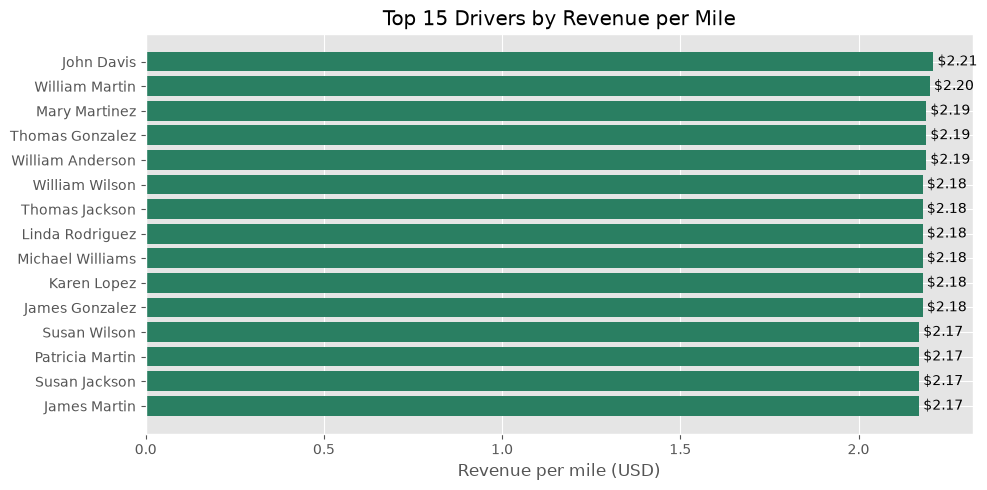

In [4]:
top15 = driver_perf.head(15)
bars = plt.barh(top15['driver_name'], top15['revenue_per_mile'], color='#2a7f62')
plt.bar_label(bars, fmt='$%.2f', padding=3)
plt.xlabel('Revenue per mile (USD)')
plt.title('Top 15 Drivers by Revenue per Mile')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

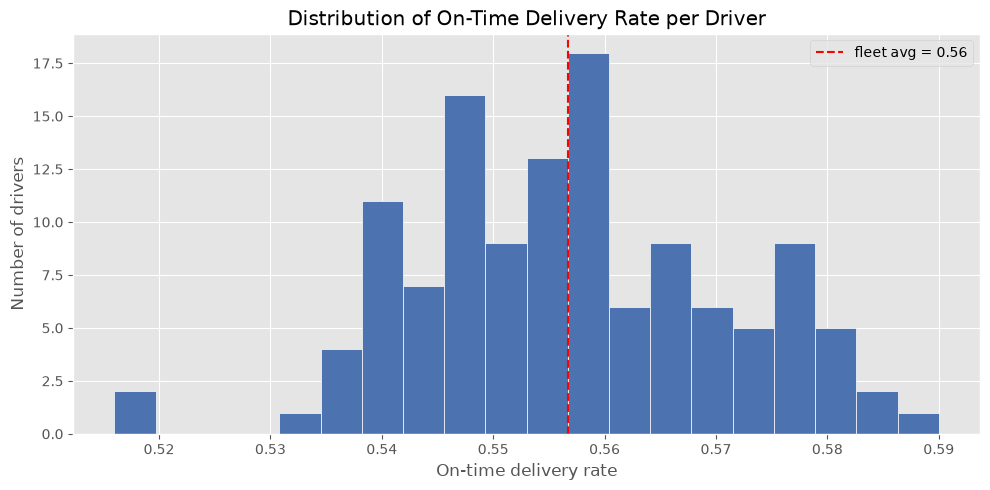

In [5]:
on_time_by_driver = q('''
SELECT
    d.driver_id, CONCAT(d.first_name, ' ', d.last_name) AS driver_name,
    COUNT(de.event_id) AS total_events,
    ROUND(SUM(CASE WHEN de.on_time_flag THEN 1 ELSE 0 END) / COUNT(de.event_id), 3) AS on_time_rate
FROM delivery_events de
JOIN trips t   ON t.trip_id = de.trip_id
JOIN drivers d ON d.driver_id = t.driver_id
GROUP BY d.driver_id, driver_name
HAVING total_events >= 20
ORDER BY on_time_rate DESC
''')
plt.hist(on_time_by_driver['on_time_rate'], bins=20, color='#4c72b0', edgecolor='white')
plt.axvline(on_time_by_driver['on_time_rate'].mean(), color='red', linestyle='--', label=f"fleet avg = {on_time_by_driver['on_time_rate'].mean():.2f}")
plt.xlabel('On-time delivery rate')
plt.ylabel('Number of drivers')
plt.title('Distribution of On-Time Delivery Rate per Driver')
plt.legend()
plt.tight_layout()
plt.show()

**Key finding:** on-time performance is spread fairly evenly around the fleet average (~0.56) rather than being driven by a few outliers — this points to a systemic issue (scheduling, detention, dock congestion) rather than a handful of underperforming drivers. Revenue-per-mile, on the other hand, only ranges narrowly (~USD 2.15-2.21) across top drivers, suggesting pay/lane assignment is fairly balanced across the fleet.

---
## 2. Route Profitability

Revenue, fuel cost, and margin by lane (origin -> destination).

In [6]:
route_profit = q('''
SELECT
    r.route_id,
    CONCAT(r.origin_city, ', ', r.origin_state, ' -> ', r.destination_city, ', ', r.destination_state) AS lane,
    r.typical_distance_miles,
    COUNT(l.load_id) AS total_loads,
    ROUND(SUM(l.revenue), 2) AS total_revenue,
    ROUND(SUM(fp.total_cost), 2) AS total_fuel_cost,
    ROUND(SUM(l.revenue) / NULLIF(SUM(t.actual_distance_miles), 0), 2) AS revenue_per_mile
FROM routes r
JOIN loads l ON l.route_id = r.route_id
JOIN trips t ON t.load_id  = l.load_id
LEFT JOIN fuel_purchases fp ON fp.trip_id = t.trip_id
GROUP BY r.route_id, lane, r.typical_distance_miles
ORDER BY total_revenue DESC
''')
route_profit.head(10)

,route_id,lane,typical_distance_miles,total_loads,total_revenue,total_fuel_cost,revenue_per_mile
0,RTE00016,"Philadelphia, PA -> Seattle, WA",2729,3479,23884705.34,1608382.40,2.44
1,RTE00029,"Seattle, WA -> Charlotte, NC",2623,3673,23804106.61,1707728.59,2.40
2,RTE00044,"Charlotte, NC -> Portland, OR",2627,3352,23729510.63,1553387.90,2.61
3,RTE00012,"Phoenix, AZ -> Philadelphia, PA",2389,3612,23418565.26,1669546.56,2.64
4,RTE00046,"Columbus, OH -> Los Angeles, CA",2269,3680,22776810.21,1721908.05,2.65
5,RTE00048,"Columbus, OH -> Portland, OR",2332,3591,22591100.29,1665771.08,2.62
6,RTE00042,"Charlotte, NC -> Seattle, WA",2623,3476,21779858.83,1615945.96,2.32
7,RTE00030,"Seattle, WA -> Indianapolis, IN",2147,3507,18677476.15,1644240.20,2.41
8,RTE00021,"Houston, TX -> Portland, OR",2108,3552,18313020.13,1643261.26,2.37
9,RTE00003,"Chicago, IL -> Los Angeles, CA",2003,3563,18156403.03,1668535.89,2.47


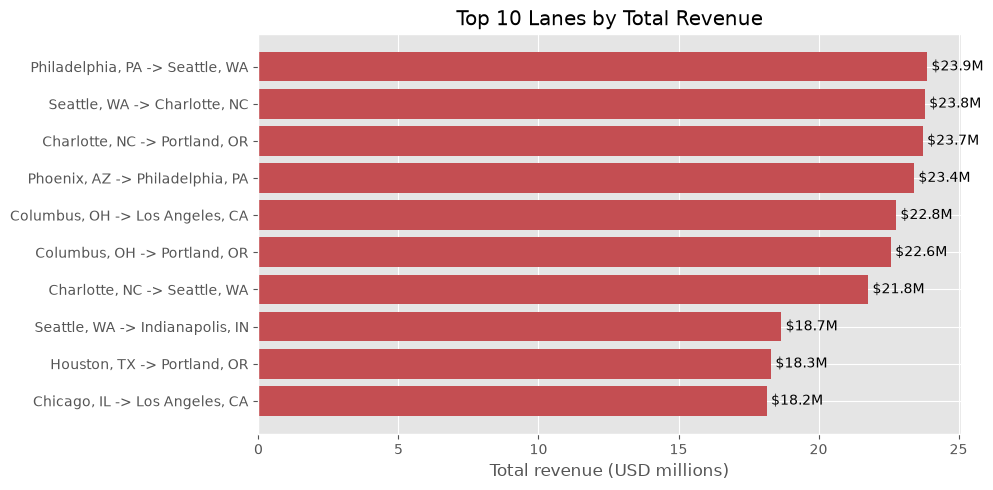

In [7]:
top10 = route_profit.head(10)
bars = plt.barh(top10['lane'], top10['total_revenue']/1e6, color='#c44e52')
plt.bar_label(bars, fmt='$%.1fM', padding=3)
plt.xlabel('Total revenue (USD millions)')
plt.title('Top 10 Lanes by Total Revenue')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Key finding:** with a minimum-volume filter (100+ loads), revenue per mile across lanes ranges from **~USD 1.48** on the weakest lane up to **~USD 2.72** on the strongest — an ~84% spread. Lanes below ~USD 1.60/mile are candidates for rate renegotiation or reduced allocation, since fuel and labor costs don't scale down proportionally with a lower rate.

---
## 3. Fleet Utilization

Miles driven and revenue generated per truck, plus monthly utilization rate.

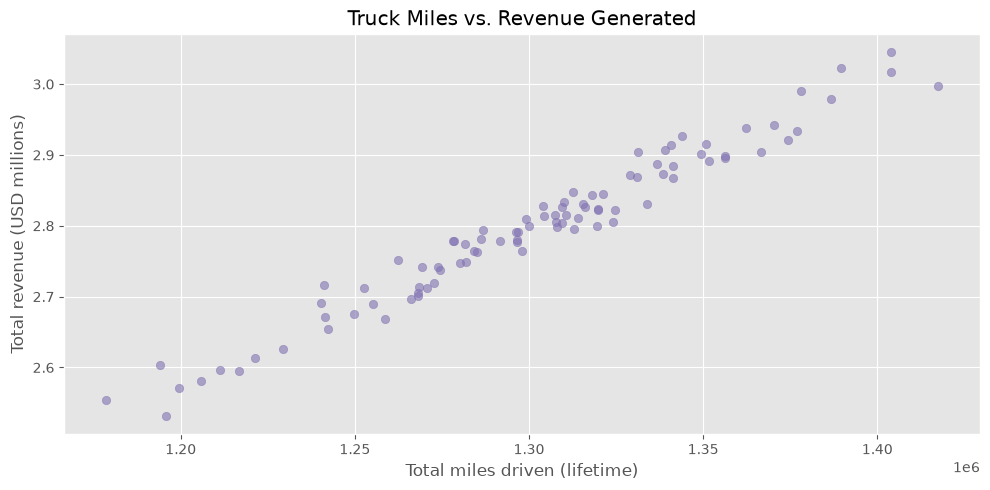

In [8]:
fleet_util = q('''
SELECT
    tr.truck_id, tr.make, tr.model_year, tr.status,
    COUNT(t.trip_id) AS total_trips,
    SUM(t.actual_distance_miles) AS total_miles,
    ROUND(SUM(l.revenue), 2) AS total_revenue
FROM trucks tr
JOIN trips t ON t.truck_id = tr.truck_id
JOIN loads l ON l.load_id  = t.load_id
GROUP BY tr.truck_id, tr.make, tr.model_year, tr.status
ORDER BY total_revenue DESC
''')

util_rate = q('''
SELECT truck_id, ROUND(AVG(utilization_rate), 3) AS avg_utilization_rate
FROM truck_utilization_metrics
GROUP BY truck_id
''')

plt.scatter(fleet_util['total_miles'], fleet_util['total_revenue']/1e6, alpha=0.6, color='#8172b2')
plt.xlabel('Total miles driven (lifetime)')
plt.ylabel('Total revenue (USD millions)')
plt.title('Truck Miles vs. Revenue Generated')
plt.tight_layout()
plt.show()

**Key finding:** revenue tracks miles almost linearly, as expected — the more useful question for a fleet manager is which trucks sit *below* the trend line (high miles, low revenue relative to peers), since those are candidates for route reassignment or a maintenance/downtime investigation (see section 4).

---
## 4. Maintenance Analysis

Cost per mile and downtime impact by truck and by maintenance type.

In [9]:
maint_by_type = q('''
SELECT maintenance_type, COUNT(*) AS num_events, ROUND(SUM(total_cost), 2) AS total_cost,
       ROUND(AVG(downtime_hours), 2) AS avg_downtime_hours
FROM maintenance_records
GROUP BY maintenance_type
ORDER BY total_cost DESC
''')
maint_by_type

,maintenance_type,num_events,total_cost,avg_downtime_hours
0,Preventive,422,963576.34,25.05
1,Repair,424,945375.44,24.65
2,Tire,414,919413.24,24.36
3,Brake,402,911667.23,24.95
4,Engine,415,890537.88,25.05
5,Transmission,411,879620.87,24.42
6,Inspection,432,220382.28,24.67


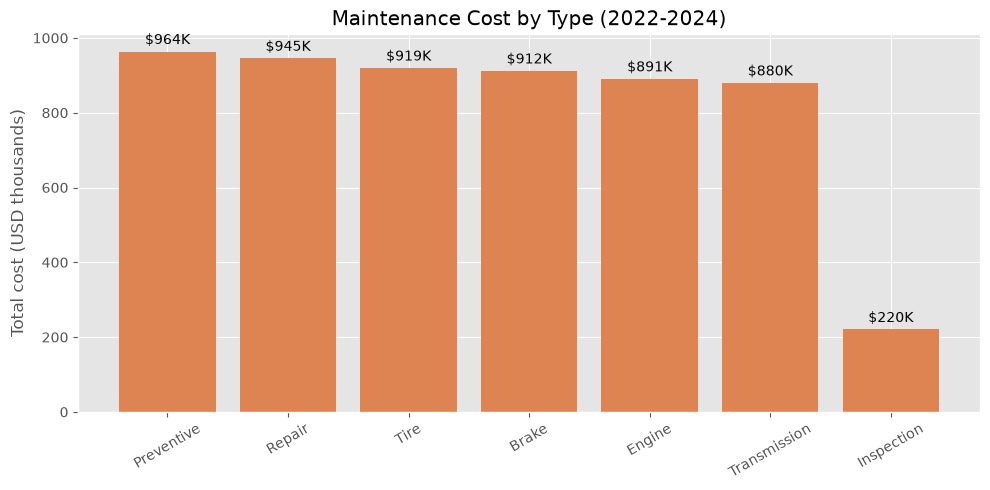

In [10]:
bars = plt.bar(maint_by_type['maintenance_type'], maint_by_type['total_cost']/1e3, color='#dd8452')
plt.bar_label(bars, fmt='$%.0fK', padding=3)
plt.ylabel('Total cost (USD thousands)')
plt.title('Maintenance Cost by Type (2022-2024)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Key finding:** costs are spread fairly evenly across Preventive, Repair, Tire, Brake, and Engine work (~USD 880K-965K each) — Inspection is the clear outlier at only ~USD 220K. This even spread suggests the fleet doesn't have one dominant failure mode; a per-truck cost-per-mile view (see `sql/03_analysis_queries.sql`, query 4a) is more useful for spotting specific problem vehicles than the type breakdown alone.

---
## 5. Fuel Efficiency

MPG trend over time and fuel price variation by state.

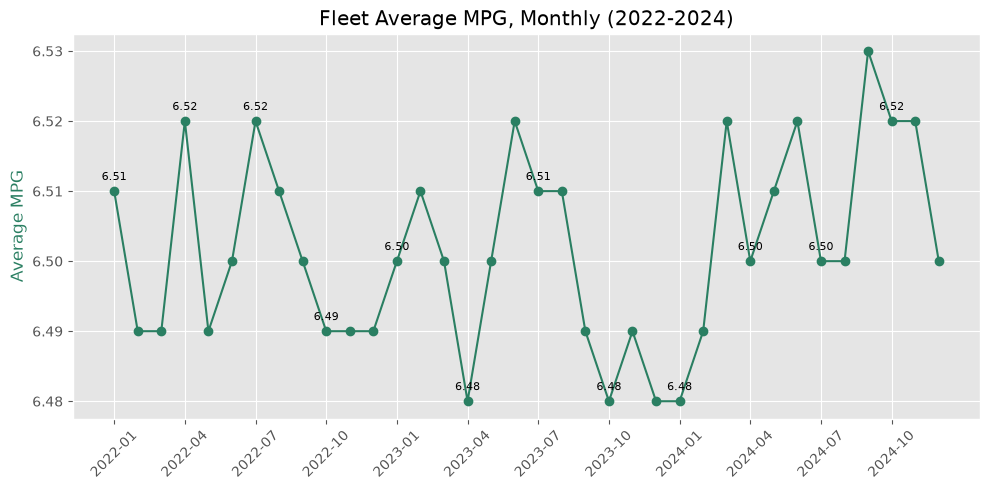

In [11]:
mpg_trend = q('''
SELECT DATE_FORMAT(t.dispatch_date, '%%Y-%%m') AS month,
       ROUND(AVG(t.average_mpg), 2) AS avg_mpg,
       ROUND(SUM(fp.total_cost), 2) AS total_fuel_cost
FROM trips t
LEFT JOIN fuel_purchases fp ON fp.trip_id = t.trip_id
GROUP BY month
ORDER BY month
''')

fig, ax1 = plt.subplots()
ax1.plot(mpg_trend['month'], mpg_trend['avg_mpg'], color='#2a7f62', marker='o')
for i in range(0, len(mpg_trend), 3):
    ax1.annotate(f"{mpg_trend['avg_mpg'][i]:.2f}",
                 (i, mpg_trend['avg_mpg'][i]),
                 textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8)
ax1.set_ylabel('Average MPG', color='#2a7f62')
ax1.set_xticks(range(0, len(mpg_trend), 3))
ax1.set_xticklabels(mpg_trend['month'][::3], rotation=45)
ax1.set_title('Fleet Average MPG, Monthly (2022-2024)')
plt.tight_layout()
plt.show()

**Key finding:** fleet average sits around **6.5 MPG** — check the monthly chart for any seasonal dip (e.g. winter months) or gradual decline over the 3 years, which would flag aging equipment or a shift toward heavier loads.

---
## 6. Customer Analysis

Revenue concentration by customer and by contract type.

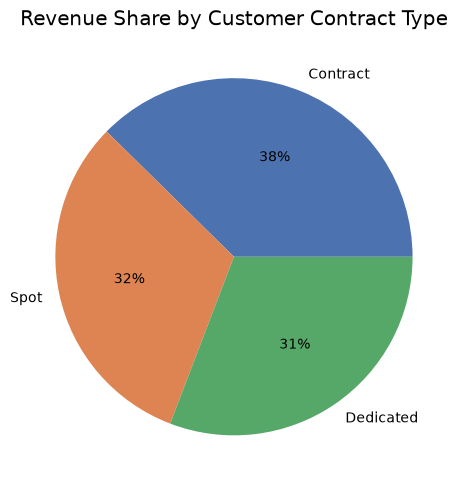

In [12]:
cust_type_rev = q('''
SELECT c.customer_type, ROUND(SUM(l.revenue), 0) AS total_revenue
FROM customers c JOIN loads l ON l.customer_id = c.customer_id
GROUP BY c.customer_type ORDER BY total_revenue DESC
''')
plt.pie(cust_type_rev['total_revenue'], labels=cust_type_rev['customer_type'], autopct='%1.0f%%',
        colors=['#4c72b0','#dd8452','#55a868'])
plt.title('Revenue Share by Customer Contract Type')
plt.tight_layout()
plt.show()

**Key finding:** Contract customers generate the largest share of revenue (~38%), ahead of Spot (~32%) and Dedicated (~31%) — a fairly balanced mix, which is generally healthier than over-reliance on the spot market (more volatile rates) or a single dedicated account (concentration risk).

In [13]:
top_customers = q('''
SELECT c.customer_id, c.customer_name, c.customer_type,
       COUNT(l.load_id) AS total_loads, ROUND(SUM(l.revenue), 2) AS total_revenue
FROM customers c JOIN loads l ON l.customer_id = c.customer_id
GROUP BY c.customer_id, c.customer_name, c.customer_type
ORDER BY total_revenue DESC
LIMIT 10
''')
top_customers

,customer_id,customer_name,customer_type,total_loads,total_revenue
0,CUST00200,XYZ Foods,Dedicated,476,1544419.81
1,CUST00181,Superior Group,Contract,497,1542321.02
2,CUST00077,Metro Group,Spot,487,1521982.07
3,CUST00097,National Wholesale,Contract,470,1487129.31
4,CUST00122,Metro Foods,Dedicated,463,1483188.90
5,CUST00028,First Group,Contract,476,1481527.84
6,CUST00110,Continental Group,Spot,481,1479584.73
7,CUST00101,United Corp,Contract,460,1477854.32
8,CUST00124,First Supply Chain,Contract,454,1472131.31
9,CUST00196,XYZ Logistics,Spot,483,1471132.90


---
## 7. Safety Metrics

Incident rate per 100,000 miles, and the preventable share of incidents.

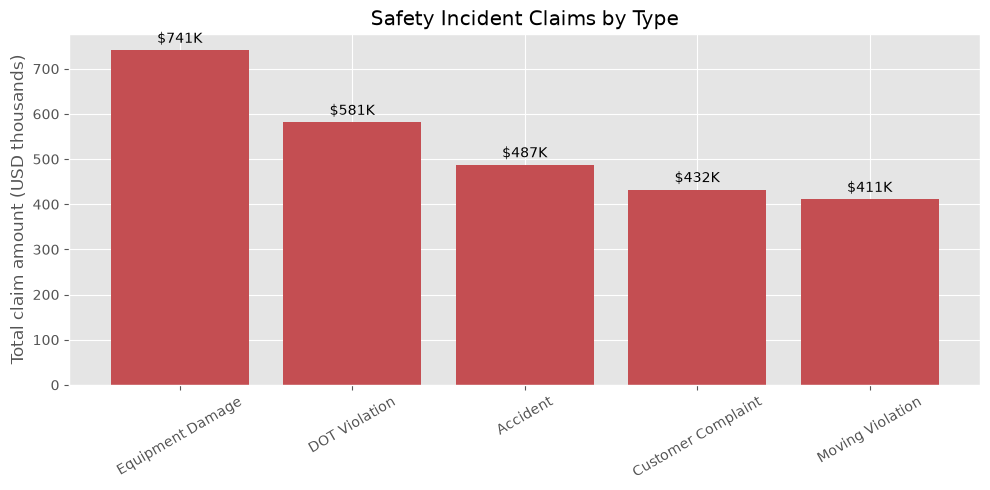

In [14]:
incident_types = q('''
SELECT incident_type, COUNT(*) AS num_incidents, ROUND(SUM(claim_amount), 2) AS total_claim
FROM safety_incidents GROUP BY incident_type ORDER BY total_claim DESC
''')
bars = plt.bar(incident_types['incident_type'], incident_types['total_claim']/1e3, color='#c44e52')
plt.bar_label(bars, fmt='$%.0fK', padding=3)
plt.ylabel('Total claim amount (USD thousands)')
plt.title('Safety Incident Claims by Type')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Key finding:** with 170 incidents across ~85,400 trips (~1.4 per 10,000 trips, or ~0.14 per 100K miles), the fleet's overall incident rate is low, but **~37.6% of incidents are flagged as preventable** — that subset is the highest-leverage target for a driver-safety coaching program, since it represents incidents the company could plausibly have avoided.

---
## 8. Seasonal Patterns

Load volume and revenue trend across the full 3-year window, and by calendar month.

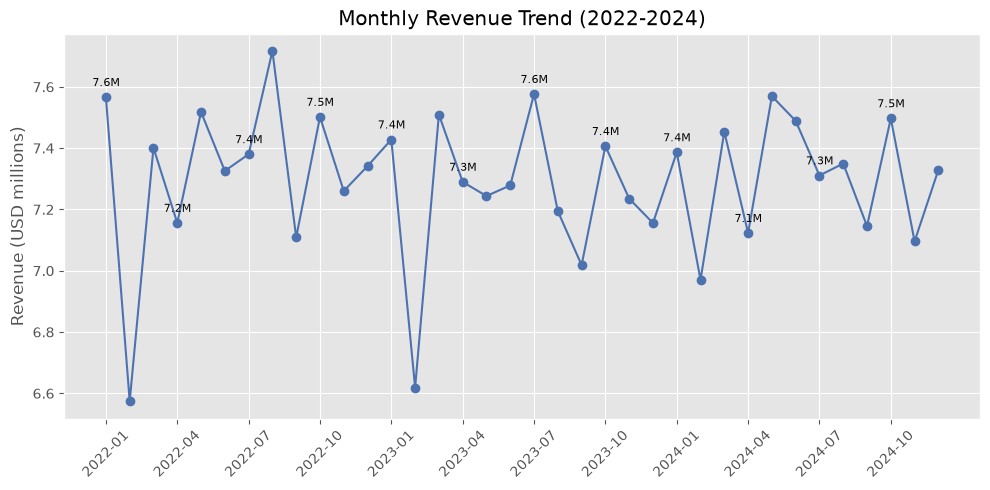

In [15]:
seasonal = q('''
SELECT DATE_FORMAT(load_date, '%%Y-%%m') AS month, COUNT(*) AS load_count, ROUND(SUM(revenue), 2) AS total_revenue
FROM loads GROUP BY month ORDER BY month
''')
plt.plot(seasonal['month'], seasonal['total_revenue']/1e6, color='#4c72b0', marker='o')
for i in range(0, len(seasonal), 3):
    plt.annotate(f"{seasonal['total_revenue'][i]/1e6:.1f}M",
                 (i, seasonal['total_revenue'][i]/1e6),
                 textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8)
plt.xticks(range(0, len(seasonal), 3), seasonal['month'][::3], rotation=45)
plt.ylabel('Revenue (USD millions)')
plt.title('Monthly Revenue Trend (2022-2024)')
plt.tight_layout()
plt.show()

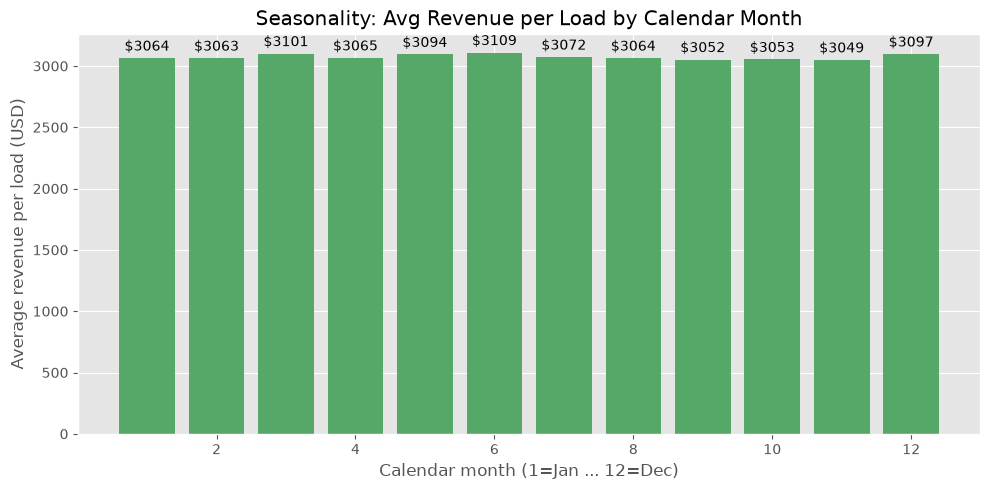

In [16]:
by_calendar_month = q('''
SELECT MONTH(load_date) AS calendar_month, ROUND(AVG(revenue), 2) AS avg_revenue_per_load
FROM loads GROUP BY calendar_month ORDER BY calendar_month
''')
bars = plt.bar(by_calendar_month['calendar_month'], by_calendar_month['avg_revenue_per_load'], color='#55a868')
plt.bar_label(bars, fmt='$%.0f', padding=3)
plt.xlabel('Calendar month (1=Jan ... 12=Dec)')
plt.ylabel('Average revenue per load (USD)')
plt.title('Seasonality: Avg Revenue per Load by Calendar Month')
plt.tight_layout()
plt.show()

**Key finding:** annual revenue is remarkably stable year-over-year (~USD 87-88M each year across 2022-2024), so growth isn't coming from volume — any YoY improvement in this business would need to come from rate optimization (see section 2) or cost control (sections 4-5) rather than expecting organic freight growth.

---
## Summary of Recommendations

1. **Fleet-wide on-time rate (~56%) is the single biggest opportunity** — investigate whether it's a scheduling/detention issue rather than a driver-skill issue, since the problem is spread evenly across drivers.
2. **Rate renegotiation on underperforming lanes** (below ~USD 1.60/mile) could lift margins without needing more volume.
3. **Preventable incidents (~38% of all incidents)** are the clear target for a driver safety-coaching initiative.
4. **Revenue has plateaued year-over-year** — profitability gains will need to come from cost and rate optimization, not volume growth.
